In [1]:
"""
Animates a regional timeseries, for a given IR channel, of brightness
temperature and its log_grad, overlaid with cloud mask.

Coded by Lucie Reymondet (Scripps-UCSD) and adapted by M. du Plessis (University of Gothenburg)
"""

# ----- Imports
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import gridspec

import cartopy.crs as ccrs

from params import base_dir, processed_goflow_inputs,\
    lon_min, lon_max, lat_min, lat_max, resolution 
# from calc_vector_grad import UVgrad
from plot_utils import plt_args, format_axes, add_box

# --------------------------------
#  Initialization
# --------------------------------
channel = "ir_105"
# channel = "ir_123"
VARS = ["BT", "loggrad_T", "loggrad_T_masked"]#, "vort", "div"] #


# ----- Plotting parameters
cbar_labelsize = 7
cbar_ticksize = 6
insert_fontsize = 8
letter_box_size = 8
letter_size = 6
from plot_utils import parameters
plt.rcParams.update(parameters)

alpha = 20
quiverscale = 3e-5
quiverwidth = 0.001
headwidth = 3
wind_scale = 10 * 110e3  # 10°

# -----------------------------
# DIRECTORIES
# -----------------------------
def fmt_lon(v):
    return f"{abs(v):.0f}{'E' if v >= 0 else 'W'}"

def fmt_lat(v):
    return f"{abs(v):.0f}{'N' if v >= 0 else 'S'}"

area_label = f"{fmt_lon(lon_min)}-{fmt_lon(lon_max)}_{fmt_lat(lat_min)}-{fmt_lat(lat_max)}"

DIR_IN = os.path.join(processed_goflow_inputs, area_label)

# base_dir = Path(__file__).resolve().parent.parent
base_dir = '/home/mduplessis/projects/DOWNLOAD_EUMETSAT/'
DIR_OUT = os.path.join(base_dir, "figures")
os.makedirs(DIR_OUT, exist_ok=True)

# -----------------------------
# DATA
# -----------------------------
ds = xr.open_dataset(os.path.join(DIR_IN,f"202605260000-202605262350_FCI-{channel}_{str(resolution).replace('.', 'p')}deg.nc"))
# u_da = ds["U"]
# v_da = ds["V"]
# _, div, vort, _ = UVgrad(u_da, v_da)
# ds["vort"] = vort
# ds["div"] = div

times = ds.time.values
n_times = 60

In [2]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 141, lat: 750, lon: 1250)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2026-05-26 ... 2026-05-26T23:...
  * lat               (lat) float64 6kB -44.99 -44.97 -44.95 ... -30.03 -30.01
  * lon               (lon) float64 10kB 10.01 10.03 10.05 ... 34.95 34.97 34.99
Data variables:
    BT                (time, lat, lon) float32 529MB ...
    loggrad_T         (time, lat, lon) float32 529MB ...
    mask              (time, lat, lon) float32 529MB ...
    loggrad_T_masked  (time, lat, lon) float32 529MB ...
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202605260000-202605262350_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

In [16]:
ds["BT_masked"] = ds["BT"].where(ds["BT"] > 278)

In [17]:
import cmocean

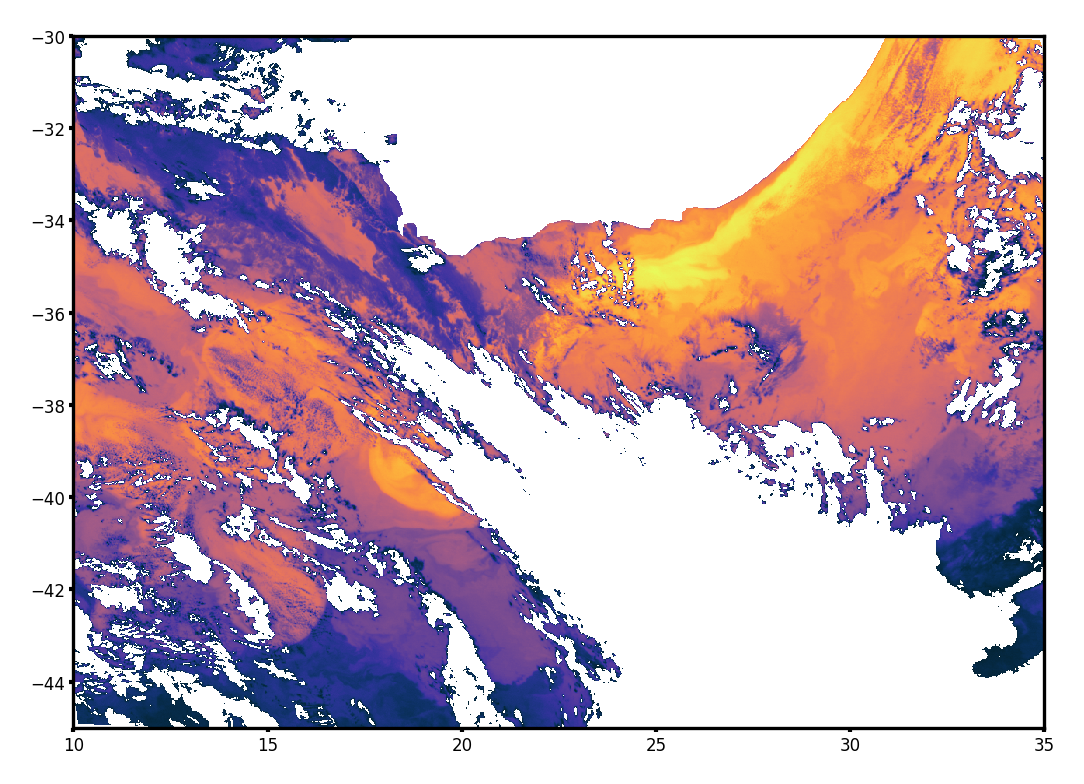

In [18]:
fig, ax = plt.subplots(figsize=(3.5, 2.5), constrained_layout=True)

ax.pcolor = ax.pcolormesh(ds.lon, ds.lat, ds["BT_masked"].isel(time=0), cmap=cmocean.cm.thermal)



In [ ]:










# ----- Domain
lon, lat = ds['lon'].values, ds['lat'].values
lon_grid, lat_grid = np.meshgrid(lon, lat)
lat_mean = np.mean(lat)
Nx = len(lon)

# ----- Train / Test / Validation regions
ll_corner = (100, 100, 100, 100)
train_inds = [
    tuple(a + b for a, b in zip(t, ll_corner))
    for t in [
        (0, 256, 0, 256),
        (0, 256, 256, 512),
        (256, 512, 0, 256),
        (256, 512, 256, 512),
        (256, 512, 512, 768),
    ]
]
test_inds = [
    tuple(a + b for a, b in zip((0, 256, 512, 768), ll_corner))
]
valid_inds = tuple(
    a + b for a, b in zip((0, 512, Nx - 768, Nx), ll_corner)
)

# -----------------------------
# PLOT
# -----------------------------
ncols = 2
nrows = 2
widths = np.ones(ncols)
heights = np.ones(nrows)
hpad, wpad = 0.02, 0.2

fig = plt.figure(figsize=(6, 3 * nrows))
gs = gridspec.GridSpec(nrows, ncols, height_ratios=heights, hspace=hpad, wspace=wpad)
axs_map = np.array([
    fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
    for i in range(nrows)
    for j in range(ncols)
])
# qp = np.empty_like(axs_map, dtype=object)

# ----- Draw static elements (gridlines, boxes, labels) using time=0
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    ax.set_aspect(1 / np.cos(np.deg2rad(lat_mean)))
    format_axes(ax, 0, 0)
    ax.coastlines(resolution='50m', color='black', linewidth=0.4)
    # Panel letters
    txq, tyq = 0.05, 0.93
    tt = ax.text(txq, tyq, '   ', weight="bold", size=letter_box_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes,
                 bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.1))
    tt.set_zorder(3)
    tt = ax.text(txq, tyq, chr(97 + v), weight="bold", size=letter_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes)

# ----- Train / test boxes on panel a
for inds in train_inds:
    add_box(axs_map[0], inds, lon, lat, 'cyan')
for inds in test_inds:
    add_box(axs_map[0], inds, lon, lat, 'k')
# add_box(ax, valid_inds, lon, lat, 'lime')

# ----- Create initial pcolormesh objects (time=0)
meshes = []
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    vmin, vmax, extend, units, title, cmap, scale, gl_color = plt_args(variable)
    data = ds[variable].isel(time=0).values * scale
    if variable=="BT":
        data -= 273 # convert to celsius
    cm = ax.pcolormesh(lon_grid, lat_grid, data,
                       shading='nearest', vmin=vmin, vmax=vmax,
                       cmap=cmap, transform=ccrs.PlateCarree())
    cbar = fig.colorbar(cm, ax=ax, orientation='horizontal',
                        extend=extend, pad=0.05, fraction=0.04)
    cbar.set_label(f'{title} [{units}]', fontsize=cbar_labelsize)
    cbar.ax.tick_params(labelsize=cbar_ticksize)
    meshes.append(cm)

# # ----- Initial quiver (time=0)
# u = ds["U"].isel(time=0).values
# v = ds["V"].isel(time=0).values
# u_qv = u[::alpha, ::alpha] / wind_scale
# v_qv = v[::alpha, ::alpha] / wind_scale
# lon_grid_qv = lon_grid[::alpha, ::alpha]
# lat_grid_qv = lat_grid[::alpha, ::alpha]
# qp[0] = axs_map[0].quiver(lon_grid_qv, lat_grid_qv, u_qv, v_qv,
#                            width=quiverwidth, scale=quiverscale,
#                            headwidth=headwidth, color='cyan')

# # ----- Quiver key
# ax = axs_map[0]
# txq, tyq = 0.86, 0.9
# tt = ax.text(txq, tyq, '             \n', weight="bold", size=8,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes,
#              bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.05))
# tt.set_zorder(2)
# tt = ax.text(txq, tyq + 0.05, 'Surface current', weight="bold", size=4,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes)
# tt.set_zorder(2)
# lkey = 1
# qt = ax.quiverkey(qp[0], X=txq, Y=tyq - 0.05, U=lkey / wind_scale,
#                   label=str(lkey) + r' m s$^{-1}$',
#                   fontproperties={'size': 3}, labelsep=0.05, coordinates="axes")
# qt.set_zorder(3)

# # ----- Time label (top of figure)
time_text = axs_map[1].text(0.5, 1.08, pd.to_datetime(times[0]).strftime("%Y-%m-%d %H:%M"),
                             ha='center', va='bottom', fontsize=7, weight='bold',
                             transform=axs_map[1].transAxes)

# --------------------------------
#  Animation update function
# --------------------------------

def update(frame):
    # Update each pcolormesh
    for v, variable in enumerate(VARS):
        _, _, _, _, _, _, scale, _ = plt_args(variable)
        data = ds[variable].isel(time=frame).values * scale
        if variable=="BT":
            data -= 273 # convert to celsius
        meshes[v].set_array(data.ravel())

    # Update quiver
    # u = ds["U"].isel(time=frame).values
    # v_arr = ds["V"].isel(time=frame).values
    # u_qv = u[::alpha, ::alpha] / wind_scale
    # v_qv = v_arr[::alpha, ::alpha] / wind_scale
    # qp[0].set_UVC(u_qv, v_qv)

    # Update time label
    time_text.set_text(pd.to_datetime(times[frame]).strftime("%Y-%m-%d %H:%M"))

    return meshes + [time_text] #+ [qp[0]] 


# ----- Build and save animation
interval_ms = 200  # ms per frame

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_times,
    interval=interval_ms,
    blit=False  # blit=False needed for cartopy axes
)

# -----------------------------
# SAVE
# -----------------------------
outfile = os.path.join(DIR_OUT, f"{channel}_snapshot_animation.gif")

writer = animation.PillowWriter(fps=5)
anim.save(outfile, writer=writer, dpi=150)

plt.close(fig)
print(f"Saved animation to {outfile}")